<a href="https://colab.research.google.com/github/Nijimbere722/lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


# Section 1

#### Part 1.1 — A single neuron is just a line

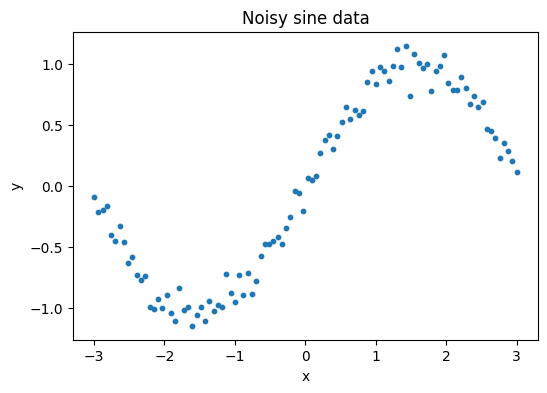

In [3]:
# Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

plt.figure(figsize=(6,4))
plt.scatter(x, y, s=10)
plt.title("Noisy sine data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [4]:
# Initialise w and b to small random values
np.random.seed(RANDOM_STATE)
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

lr = 0.1
steps = 200
losses = []

for step in range(steps):
    # Forward pass
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Update
    w -= lr * dw
    b -= lr * db

print(f"Final w: {w:.4f}, b: {b:.4f}")
print(f"Final loss: {losses[-1]:.4f}")

Final w: 0.3390, b: -0.0104
Final loss: 0.1955


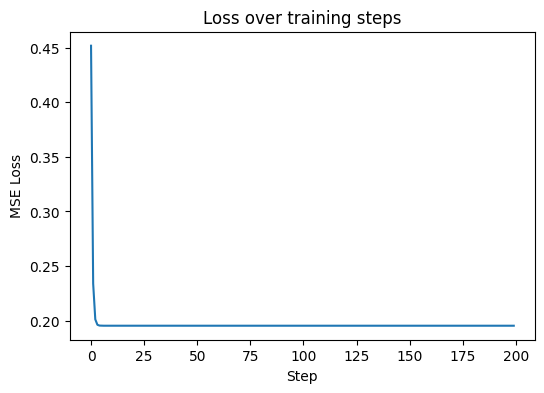

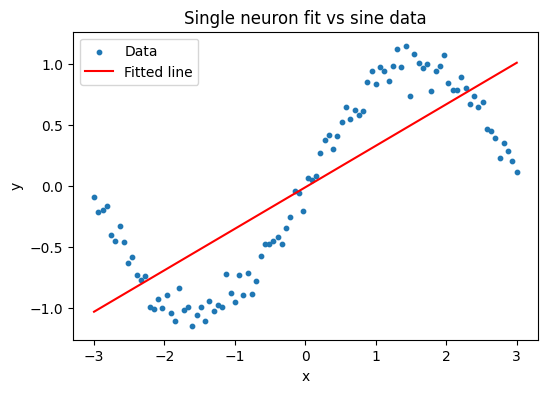

In [5]:
# Plot loss curve
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Loss over training steps")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()

# Plot data with fitted line
plt.figure(figsize=(6,4))
plt.scatter(x, y, s=10, label="Data")
plt.plot(x, w*x + b, color="red", label="Fitted line")
plt.title("Single neuron fit vs sine data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

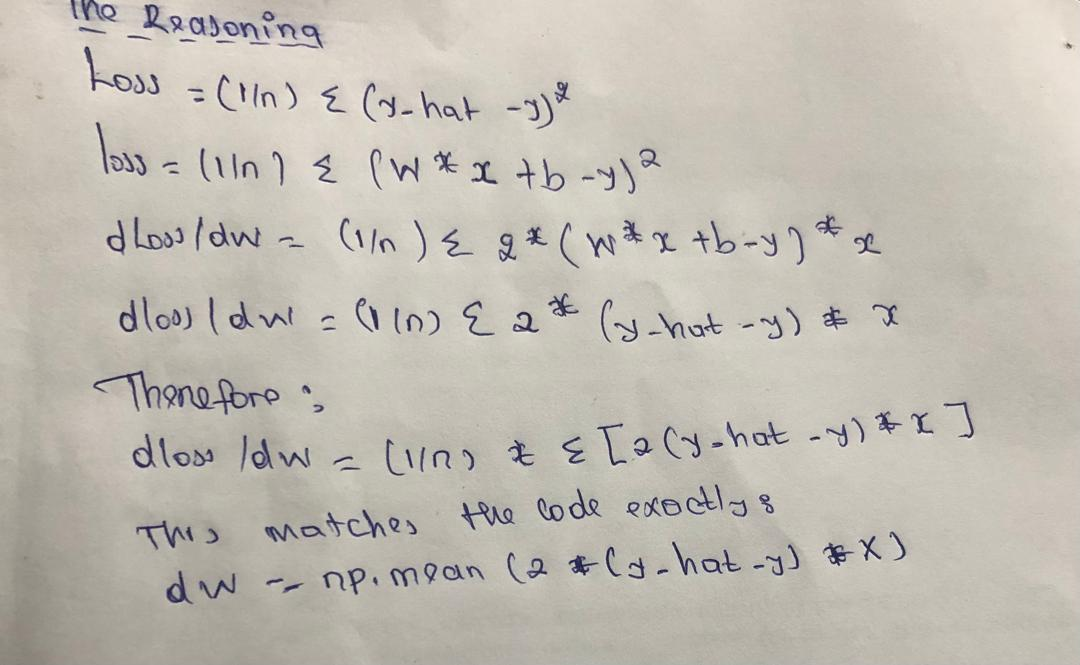

#### Part 1.2

In [6]:
# Initialise parameters
np.random.seed(RANDOM_STATE)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

lr = 0.05
steps = 3000
losses_hidden = []

x_col = x.reshape(-1, 1)
y_col = y.reshape(-1, 1)

for step in range(steps):
    # Forward pass
    z1 = x_col @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y_col) ** 2)
    losses_hidden.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat - y_col) / len(y_col)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x_col.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

print(f"Final loss: {losses_hidden[-1]:.4f}")

Final loss: 0.0150


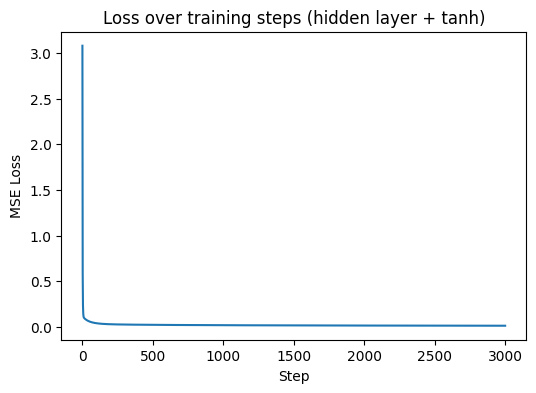

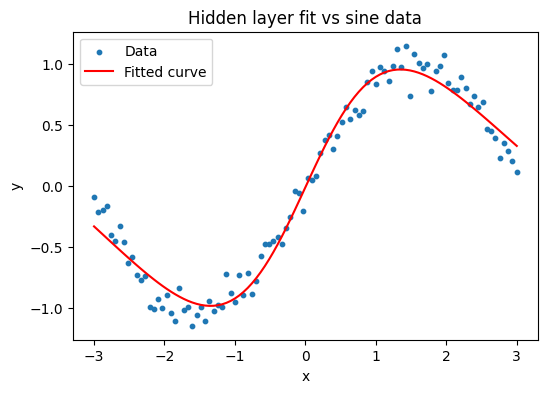

In [7]:
# Plot loss curve and final fit
plt.figure(figsize=(6,4))
plt.plot(losses_hidden)
plt.title("Loss over training steps (hidden layer + tanh)")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(x, y, s=10, label="Data")
plt.plot(x, y_hat, color="red", label="Fitted curve")
plt.title("Hidden layer fit vs sine data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Final loss (no tanh): 0.1955


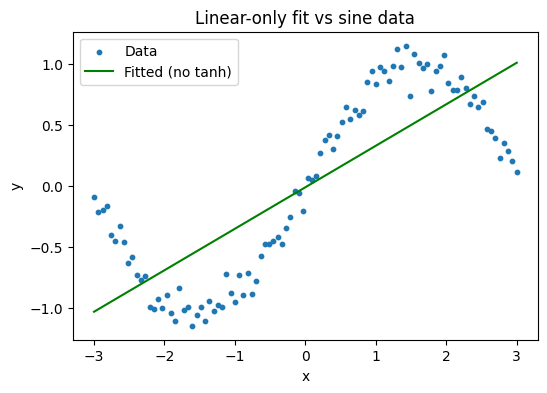

In [8]:
# Re-run WITHOUT tanh (linear only)
np.random.seed(RANDOM_STATE)
W1_lin = np.random.randn(1, 8) * 0.5
b1_lin = np.zeros(8)
W2_lin = np.random.randn(8, 1) * 0.5
b2_lin = np.zeros(1)

losses_linear = []

for step in range(steps):
    z1 = x_col @ W1_lin + b1_lin
    h = z1
    y_hat_lin = h @ W2_lin + b2_lin
    loss = np.mean((y_hat_lin - y_col) ** 2)
    losses_linear.append(loss)

    d_yhat = 2 * (y_hat_lin - y_col) / len(y_col)
    dW2_lin = h.T @ d_yhat
    db2_lin = d_yhat.sum(axis=0)
    dh = d_yhat @ W2_lin.T
    dz1 = dh
    dW1_lin = x_col.T @ dz1
    db1_lin = dz1.sum(axis=0)

    W1_lin -= lr * dW1_lin
    b1_lin -= lr * db1_lin
    W2_lin -= lr * dW2_lin
    b2_lin -= lr * db2_lin

print(f"Final loss (no tanh): {losses_linear[-1]:.4f}")

plt.figure(figsize=(6,4))
plt.scatter(x, y, s=10, label="Data")
plt.plot(x, y_hat_lin, color="green", label="Fitted (no tanh)")
plt.title("Linear-only fit vs sine data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

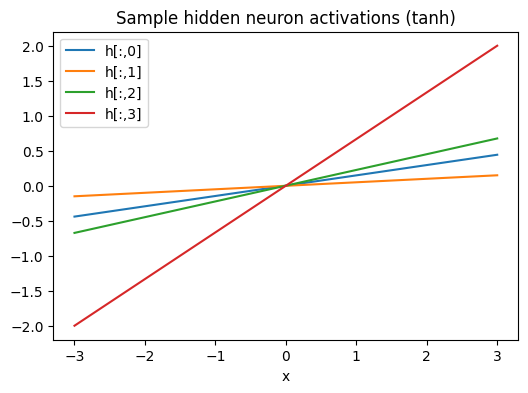

In [9]:
# plot first 4 hidden neurons
plt.figure(figsize=(6,4))
for i in range(4):
    plt.plot(x, h[:, i], label=f"h[:,{i}]")
plt.title("Sample hidden neuron activations (tanh)")
plt.xlabel("x")
plt.legend()
plt.show()

## Reasoning

1.Without tanh, the network computes y_hat = (x·W1 + b1)·W2 + b2, which simplifies to x·(W1·W2) + (b1·W2 + b2). This is just w*x + b with a new combined weight and bias algebraically identical to a single linear layer, no matter how many linear layers you stack. That's why it matched Part 1.1's loss of 0.1955.

2.Each of the 8 hidden neurons learns its own tanh-shaped bend of x, activating at a different point. The output layer combines these 8 curved pieces into one smooth curve, like building a sine wave out of several overlapping S-curves. This is only possible because tanh is nonlinear; without it, there's nothing to combine into a curve.

3.Backpropagation is using the chain rule to work backward from the loss and calculate how much each weight and bias contributed to the error.

#### Part 1.3

In [11]:
import warnings
warnings.filterwarnings("ignore")
np.seterr(all="ignore")

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [13]:
import warnings
warnings.filterwarnings("ignore")
np.seterr(all="ignore")

def train_toy(lr, steps=3000):
    np.random.seed(RANDOM_STATE)
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)

    losses = []
    for step in range(steps):
        z1 = x_col @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y_col) ** 2)
        losses.append(loss)

        d_yhat = 2 * (y_hat - y_col) / len(y_col)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x_col.T @ dz1
        db1 = dz1.sum(axis=0)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return losses

losses_low = train_toy(lr=0.001)
losses_mid = train_toy(lr=0.05)
losses_high = train_toy(lr=1.0)

print("Final loss (lr=0.001):", losses_low[-1])
print("Final loss (lr=0.05):", losses_mid[-1])
print("Final loss (lr=1.0):", losses_high[-1])

Final loss (lr=0.001): 0.05549205437766945
Final loss (lr=0.05): 0.015034009965287823
Final loss (lr=1.0): nan


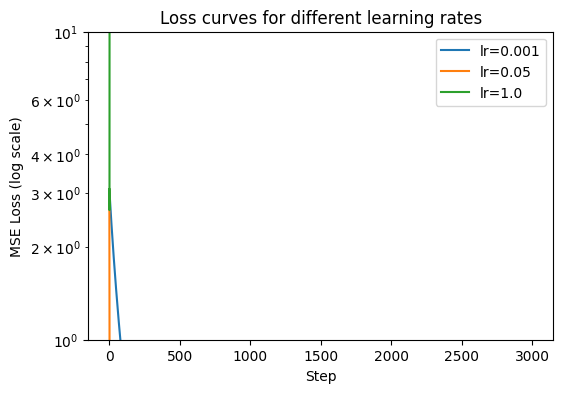

In [14]:
plt.figure(figsize=(6,4))
plt.plot(losses_low, label="lr=0.001")
plt.plot(losses_mid, label="lr=0.05")
plt.plot(losses_high, label="lr=1.0")
plt.yscale("log")
plt.title("Loss curves for different learning rates")
plt.xlabel("Step")
plt.ylabel("MSE Loss (log scale)")
plt.legend()
plt.show()

#### Reasoning

lr=0.001 (too cold): The loss barely decreases over 3000 steps — each update is too small, so the model learns extremely slowly and never reaches a good fit in the given time.

lr=0.05 (just right): The loss drops quickly and smoothly, settling at a low value (~0.015). this is a well-balanced step size for this problem.

lr=1.0 (too hot): The loss explodes to nan almost immediately. A learning rate this large causes each weight update to overshoot the minimum by such a large margin that the weights grow uncontrollably with every step, eventually exceeding what a computer can represent numerically. It's not "learning faster"  it's failing to converge at all, since each step moves further from the minimum instead of closer to it.